## 4번 세그먼트: 대중성 & 팬덤 상위권 후보군

4번 세그먼트는 플랫폼 내 대중성, 방송 화력, 팬덤 체급, 외부 유입 가능성을 함께 가진 스트리머를 찾기 위한 세그먼트이다.

이번 분석에서는 팀 피드백을 반영해 가중치를 조정하고, 전체 TOP 후보군 중심으로 결과를 확인한다.

> 팬카페 그룹 여부 및 소속구분은 이번 후보군 선정의 주요 판단 기준에서 제외했다.


### 라이브러리

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import math
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv("../data/final_softcone_for_team.csv")

# 윈도우 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
df

,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,소속
0,탬탬버린,CHZZK,a7e175625fdea5a7d98428302b7aa57f,2025.01.01 ~ 2026.03.31,308659,2769,5923,2346,23115,13532,17075004,6876167,4.4,-13.9,0,537000,46191,NaN
1,텐코 시부키,CHZZK,64d76089fba26b180d9c9e48a32600d9,2025.01.01 ~ 2026.03.31,222276,2368,7255,4660,34645,16465,14216251,6737178,-0.7,4.1,78000,204000,252724,스텔라이브
2,아리사,CHZZK,4de764d9dad3b25602284be6db3ac647,2025.01.01 ~ 2026.03.31,84836,4218,7123,3100,12994,8066,11904276,6932861,-0.8,-6.2,7028,77600,30431,에스더
3,아라하시 타비,CHZZK,a6c4ddb09cdb160478996007bff35296,2025.01.01 ~ 2026.03.31,232937,2409,6976,4840,28568,12483,11350960,6733563,-0.1,4.0,89000,230000,252724,스텔라이브
4,고세구,SOOP,gosegu2,2025.01.01 ~ 2026.03.31,199696,1558,95063,17283,39102,23877,10855404,5905590,8.2,9.8,0,545000,573411,이세계아이돌
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11152,sophiaten,SOOP,sophiaten,2026.03.20 ~ 2026.03.20,5,1,0,0,2,0,0,0,361.5,-100.0,0,3900,0,NaN
11153,한유0612,CHZZK,e982cd3a6093de657fa34db1bc42e98a,2026.03.30 ~ 2026.03.30,22,0,0,0,0,0,0,0,-100.0,-100.0,0,0,0,NaN
11154,dj12jdhs,SOOP,dj12jdhs,2026.03.08 ~ 2026.03.08,0,0,4,2,3,3,0,0,0.0,0.0,0,0,0,NaN
11155,afueo039,SOOP,afueo039,2025.01.21 ~ 2026.03.10,2,18,2,2,2,2,0,0,-100.0,-100.0,0,0,0,NaN


In [4]:
df.head()

,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,소속
0,탬탬버린,CHZZK,a7e175625fdea5a7d98428302b7aa57f,2025.01.01 ~ 2026.03.31,308659,2769,5923,2346,23115,13532,17075004,6876167,4.4,-13.9,0,537000,46191,NaN
1,텐코 시부키,CHZZK,64d76089fba26b180d9c9e48a32600d9,2025.01.01 ~ 2026.03.31,222276,2368,7255,4660,34645,16465,14216251,6737178,-0.7,4.1,78000,204000,252724,스텔라이브
2,아리사,CHZZK,4de764d9dad3b25602284be6db3ac647,2025.01.01 ~ 2026.03.31,84836,4218,7123,3100,12994,8066,11904276,6932861,-0.8,-6.2,7028,77600,30431,에스더
3,아라하시 타비,CHZZK,a6c4ddb09cdb160478996007bff35296,2025.01.01 ~ 2026.03.31,232937,2409,6976,4840,28568,12483,11350960,6733563,-0.1,4.0,89000,230000,252724,스텔라이브
4,고세구,SOOP,gosegu2,2025.01.01 ~ 2026.03.31,199696,1558,95063,17283,39102,23877,10855404,5905590,8.2,9.8,0,545000,573411,이세계아이돌


In [5]:
df.columns

Index(['스트리머명', '플랫폼', '채널ID', '집계기간_내_최초_방송일', '최고_팔로워', '총_방송시간', '6분_최고채팅',
       '6분_평균채팅_최댓값', '최고_시청자', '평균_시청자_최댓값', '뷰어십', '도네이션', '유튜브_유입지수',
       '팬덤지수', 'X_팔로워', '유튜브_구독자', '팬카페_가입자', '소속'],
      dtype='str')

---
### 세그먼트 점수 산정 방식

4번 세그먼트 점수는 ‘대중성과 외부 팬덤 기반이 강한 후보군’을 찾기 위해  
다음 세 가지 축으로 구성했다.

1. **대중성**
   - 유튜브 유입지수
   - 최고 팔로워
   - 최고 시청자

2. **방송 화력**
   - 도네이션
   - 6분 최고채팅
   - 평균 시청자 최댓값

3. **팬덤 체급**
   - 유튜브 구독자
   - 뷰어십
   - 팬덤지수

값의 범위가 큰 지표는 `log1p` 변환을 적용해 극단값의 영향을 완화했고,  
이후 모든 지표를 0~100점으로 정규화한 뒤 가중합하여 최종 점수를 계산했다.


## 최종 계산식

4번 세그먼트 점수는 팀 피드백을 반영해 다음과 같이 조정했다.

### 1. 대중성 점수

대중성 점수는 외부 유입 가능성을 더 강하게 보기 위해 유튜브 유입지수의 비중을 높이고,  
플랫폼 내 기존 체급을 나타내는 최고 팔로워와 최고 시청자를 함께 반영했다.

**대중성 점수 = 유튜브유입지수 50% + 최고시청자 30% + 최고팔로워 20%**

---

### 2. 방송화력 점수

방송화력 점수는 기존 방식과 동일하게 실제 방송 중 발생하는 후원, 채팅, 평균 시청자 반응을 중심으로 계산했다.

**방송화력 점수 = 도네이션 40% + 채팅화력 30% + 평균시청자 30%**

---

### 3. 팬덤체급 점수

팬덤체급 점수는 외부 팬덤 규모와 누적 방송 소비 규모를 중심으로 조정했다.  
유튜브 구독자와 뷰어십을 각각 40%로 두고, 팬덤지수는 보조 지표로 20% 반영했다.

**팬덤체급 점수 = 유튜브구독자 40% + 팬덤지수 20% + 뷰어십 40%**

---

### 4. 최종 세그먼트 점수

최종 세그먼트 점수는 4번 세그먼트의 목적에 맞게 대중성을 가장 크게 반영하고,  
팬덤체급과 방송화력은 동일한 보조 비중으로 반영했다.

**최종 세그먼트 점수 = 대중성 50% + 팬덤체급 25% + 방송화력 25%**

---

### 지표 반영 기준

4번 세그먼트는 플랫폼 내 방송 성과만 보는 것이 아니라,  
외부 유입 가능성과 팬덤 규모까지 함께 가진 후보군을 찾는 목적이므로  
대중성과 팬덤체급의 비중을 기존보다 높게 조정했다.


In [6]:
seg4_df = df.copy()

score_cols = [
    "최고_팔로워",
    "최고_시청자",
    "유튜브_유입지수",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "팬덤지수",
    "뷰어십",
    "유튜브_구독자"
]


for col in score_cols:
    seg4_df[col] = pd.to_numeric(seg4_df[col], errors="coerce").fillna(0)

# 값 차이가 큰 지표는 로그 변환
log_cols = [
    "최고_팔로워",
    "최고_시청자",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "뷰어십",
    "유튜브_구독자"
]

for col in log_cols:
    seg4_df[f"log_{col}"] = np.log1p(seg4_df[col])

# 유튜브_유입지수, 팬덤지수는 음수 가능성이 있으므로 로그 변환하지 않음
scale_input_cols = [
    "log_최고_팔로워",
    "log_최고_시청자",
    "유튜브_유입지수",
    "log_도네이션",
    "log_6분_최고채팅",
    "log_평균_시청자_최댓값",
    "팬덤지수",
    "log_뷰어십",
    "log_유튜브_구독자"
]

scaled_cols = [
    "팔로워_score",
    "최고시청자_score",
    "유튜브유입_score",
    "도네이션_score",
    "채팅화력_score",
    "평균시청자_score",
    "팬덤지수_score",
    "뷰어십_score",
    "유튜브구독자_score"
]


scaler = MinMaxScaler()

# scale_input_cols와 scaled_cols는 순서대로 1:1 매칭됨
seg4_df[scaled_cols] = scaler.fit_transform(seg4_df[scale_input_cols]) * 100

In [7]:
# 1. 대중성 점수 : 외부 유입 가능성과 플랫폼 내 체급을 함께 반영
# 유튜브유입은 외부 채널에서 방송 플랫폼으로 유입될 가능성을 보여주는 핵심 지표이므로 50% 반영
# 최고시청자는 순간 화제성과 흥행력을 보여주므로 30% 반영
# 팔로워는 플랫폼 내 기존 인지도/체급을 보여주므로 20% 반영
seg4_df["대중성_score"] = (
    seg4_df["유튜브유입_score"] * 0.50 +
    seg4_df["최고시청자_score"] * 0.30 +
    seg4_df["팔로워_score"] * 0.20
)

# 2. 방송화력 점수 : 기존 방식 유지
# 도네이션은 시청자의 직접적 후원 행동이므로 40% 반영
# 채팅은 실시간 참여도, 평균 시청자는 안정적인 시청 기반을 의미하므로 각각 30% 반영
seg4_df["방송화력_score"] = (
    seg4_df["도네이션_score"] * 0.40 +
    seg4_df["채팅화력_score"] * 0.30 +
    seg4_df["평균시청자_score"] * 0.30
)

# 3. 팬덤체급 점수 : 외부 팬덤 규모와 누적 시청 규모를 중심으로 조정
# 유튜브구독자는 외부 플랫폼에서 확보한 팬덤 규모를 의미하므로 40% 반영
# 뷰어십은 누적 방송 소비 규모를 의미하므로 40% 반영
# 팬덤지수는 결측/간접성 가능성이 있어 보조 지표로 20% 반영
seg4_df["팬덤체급_score"] = (
    seg4_df["유튜브구독자_score"] * 0.40 +
    seg4_df["팬덤지수_score"] * 0.20 +
    seg4_df["뷰어십_score"] * 0.40
)

# 4. 최종 세그먼트4 점수
# 4번 세그먼트는 대중성과 외부 팬덤 확장 가능성을 더 중점적으로 보기 위한 후보군이므로 대중성 비중을 가장 높게 설정
seg4_df["세그먼트4_score"] = (
    seg4_df["대중성_score"] * 0.50 +
    seg4_df["팬덤체급_score"] * 0.25 +
    seg4_df["방송화력_score"] * 0.25
)


In [8]:
result_cols = [
    "스트리머명",
    "플랫폼",
    "최고_팔로워",
    "최고_시청자",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "유튜브_유입지수",
    "유튜브_구독자",
    "팬덤지수",
    "뷰어십",
    "대중성_score",
    "방송화력_score",
    "팬덤체급_score",
    "세그먼트4_score",
    "소속"
]

seg4_result = (
    seg4_df[result_cols]
    .sort_values("세그먼트4_score", ascending=False)
    .reset_index(drop=True)
)

seg4_result.head()


,스트리머명,플랫폼,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤체급_score,세그먼트4_score,소속
0,고세구,SOOP,199696,39102,5905590,95063,23877,8.2,545000,9.8,10855404,54.253498,98.459542,79.165856,71.533099,이세계아이돌
1,시라유키 히나,CHZZK,219675,47218,6864206,6960,30958,2.6,302000,4.4,8608945,54.620978,92.830024,76.791456,69.715859,스텔라이브
2,주르르,SOOP,175519,27415,3250999,55406,17295,7.2,417000,11.0,4794346,53.009609,94.612701,76.514593,69.286628,이세계아이돌
3,비챤,SOOP,176315,20891,2862540,108416,16694,5.2,331000,10.9,5657369,52.149919,95.924277,76.276027,69.125035,이세계아이돌
4,아카네 리제,CHZZK,235506,40960,6069644,5873,23109,2.5,319000,3.9,5983879,54.326821,91.230281,76.049127,68.983262,스텔라이브


# 전체 TOP 보기

In [9]:
seg4_result.head(30)

,스트리머명,플랫폼,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤체급_score,세그먼트4_score,소속
0,고세구,SOOP,199696,39102,5905590,95063,23877,8.2,545000,9.8,10855404,54.253498,98.459542,79.165856,71.533099,이세계아이돌
1,시라유키 히나,CHZZK,219675,47218,6864206,6960,30958,2.6,302000,4.4,8608945,54.620978,92.830024,76.791456,69.715859,스텔라이브
2,주르르,SOOP,175519,27415,3250999,55406,17295,7.2,417000,11.0,4794346,53.009609,94.612701,76.514593,69.286628,이세계아이돌
3,비챤,SOOP,176315,20891,2862540,108416,16694,5.2,331000,10.9,5657369,52.149919,95.924277,76.276027,69.125035,이세계아이돌
4,아카네 리제,CHZZK,235506,40960,6069644,5873,23109,2.5,319000,3.9,5983879,54.326821,91.230281,76.049127,68.983262,스텔라이브
5,탬탬버린,CHZZK,308659,23115,6876167,5923,13532,4.4,537000,-13.9,17075004,53.254149,90.016164,79.331147,68.963902,NaN
6,릴파,SOOP,185167,21790,5796867,13983,18865,7.0,434000,10.5,7788723,52.441361,92.769388,77.770914,68.855756,이세계아이돌
7,텐코 시부키,CHZZK,222276,34645,6737178,7255,16465,-0.7,204000,4.1,14216251,53.596017,91.058295,76.910885,68.790304,스텔라이브
8,유즈하 리코,CHZZK,183957,36983,6609127,7092,21539,0.0,183000,5.6,6673506,53.523651,91.730136,74.852816,68.407563,스텔라이브
9,아야츠노 유니,CHZZK,281741,21414,6715398,6674,14086,1.7,347000,2.8,10770780,52.752609,90.381397,77.650340,68.384239,스텔라이브


# 세그먼트 점수 60점/65점/70점이상

In [10]:
# 60점이상
seg4_60plus = (
    seg4_result[seg4_result["세그먼트4_score"] >= 60]
    .sort_values("세그먼트4_score", ascending=False)
    .copy()
)

print(f"60점 이상 후보군 수: {len(seg4_60plus)}명")
seg4_60plus[
    [
        "스트리머명",
        "세그먼트4_score",
        "대중성_score",
        "방송화력_score",
        "팬덤체급_score",
        "소속"
    ]
]

60점 이상 후보군 수: 100명


,스트리머명,세그먼트4_score,대중성_score,방송화력_score,팬덤체급_score,소속
0,고세구,71.533099,54.253498,98.459542,79.165856,이세계아이돌
1,시라유키 히나,69.715859,54.620978,92.830024,76.791456,스텔라이브
2,주르르,69.286628,53.009609,94.612701,76.514593,이세계아이돌
3,비챤,69.125035,52.149919,95.924277,76.276027,이세계아이돌
4,아카네 리제,68.983262,54.326821,91.230281,76.049127,스텔라이브
...,...,...,...,...,...,...
95,리타,60.286509,49.429915,84.006763,58.279443,NaN
96,한결,60.279910,47.316833,88.033943,58.452031,이브닛
97,구슬요,60.229533,47.013504,82.330301,64.560825,NaN
98,유세라,60.217070,46.113435,82.277874,66.363537,NaN


In [11]:
print("60점이상")
seg4_60plus["소속"].astype(str).str.strip().value_counts(dropna=False)

60점이상


소속
NaN       60
스텔라이브     11
이세계아이돌     6
프로젝트아이     6
에스더        4
싸이코드       2
하데스        2
이브닛        2
오버더월       2
블루점프       1
도파민        1
베이라이트      1
프리아        1
왁타버스       1
Name: count, dtype: int64

In [12]:
# 60점이상 소속이 결측(NaN)인 사람만 보기
seg4_nan_group = seg4_60plus[
    seg4_60plus["소속"].isna()
].copy()

print(f"60점 이상 후보군 중 소속 NaN 수: {len(seg4_nan_group)}명")

seg4_nan_group[
    [
        "스트리머명",
        "세그먼트4_score",
        "대중성_score",
        "방송화력_score",
        "팬덤체급_score",
        "소속"
    ]
]

60점 이상 후보군 중 소속 NaN 수: 60명


,스트리머명,세그먼트4_score,대중성_score,방송화력_score,팬덤체급_score,소속
5,탬탬버린,68.963902,53.254149,90.016164,79.331147,NaN
20,천양,65.363197,49.236403,88.784809,74.195172,NaN
22,민결희,65.143122,49.353439,92.610899,69.254710,NaN
23,마이곰이,64.900581,49.352328,91.473282,69.424387,NaN
24,유소나,64.663937,51.423190,84.387124,71.422246,NaN
25,백곰파,64.624167,50.393781,88.179743,69.529363,NaN
26,깐숙,64.564922,49.457070,91.694023,67.651523,NaN
28,양아지,64.298729,49.155443,84.283198,74.600834,NaN
29,마뫄,64.223007,49.737452,84.133964,73.283159,NaN
30,조디악악악,64.135753,50.279253,88.429930,67.554577,NaN


In [13]:
seg4_65plus = (
    seg4_result[seg4_result["세그먼트4_score"] >= 65]
    .sort_values("세그먼트4_score", ascending=False)
    .copy()
)

print(f"65점 이상 후보군 수: {len(seg4_65plus)}명")
seg4_65plus[
    [
        "스트리머명",
        "세그먼트4_score",
        "대중성_score",
        "방송화력_score",
        "팬덤체급_score",
        "소속"
    ]
]

65점 이상 후보군 수: 23명


,스트리머명,세그먼트4_score,대중성_score,방송화력_score,팬덤체급_score,소속
0,고세구,71.533099,54.253498,98.459542,79.165856,이세계아이돌
1,시라유키 히나,69.715859,54.620978,92.830024,76.791456,스텔라이브
2,주르르,69.286628,53.009609,94.612701,76.514593,이세계아이돌
3,비챤,69.125035,52.149919,95.924277,76.276027,이세계아이돌
4,아카네 리제,68.983262,54.326821,91.230281,76.049127,스텔라이브
5,탬탬버린,68.963902,53.254149,90.016164,79.331147,NaN
6,릴파,68.855756,52.441361,92.769388,77.770914,이세계아이돌
7,텐코 시부키,68.790304,53.596017,91.058295,76.910885,스텔라이브
8,유즈하 리코,68.407563,53.523651,91.730136,74.852816,스텔라이브
9,아야츠노 유니,68.384239,52.752609,90.381397,77.650340,스텔라이브


In [14]:
print("65점이상")
seg4_65plus["소속"].astype(str).str.strip().value_counts(dropna=False)

65점이상


소속
스텔라이브     11
이세계아이돌     6
NaN        3
블루점프       1
프로젝트아이     1
에스더        1
Name: count, dtype: int64

In [15]:
# 65점이상 소속이 결측(NaN)인 사람만 보기
seg4_nan_group = seg4_65plus[
    seg4_65plus["소속"].isna()
].copy()

print(f"65점 이상 후보군 중 소속 NaN 수: {len(seg4_nan_group)}명")

seg4_nan_group[
    [
        "스트리머명",
        "세그먼트4_score",
        "대중성_score",
        "방송화력_score",
        "팬덤체급_score",
        "소속"
    ]
]

65점 이상 후보군 중 소속 NaN 수: 3명


,스트리머명,세그먼트4_score,대중성_score,방송화력_score,팬덤체급_score,소속
5,탬탬버린,68.963902,53.254149,90.016164,79.331147,NaN
20,천양,65.363197,49.236403,88.784809,74.195172,NaN
22,민결희,65.143122,49.353439,92.610899,69.254710,NaN


In [16]:
#70점이상
seg4_70plus = (
    seg4_result[seg4_result["세그먼트4_score"] >= 70]
    .sort_values("세그먼트4_score", ascending=False)
    .copy()
)

print(f"70점 이상 후보군 수: {len(seg4_70plus)}명")
seg4_70plus[
    [
        "스트리머명",
        "세그먼트4_score",
        "대중성_score",
        "방송화력_score",
        "팬덤체급_score",
        "소속"
    ]
]

70점 이상 후보군 수: 1명


,스트리머명,세그먼트4_score,대중성_score,방송화력_score,팬덤체급_score,소속
0,고세구,71.533099,54.253498,98.459542,79.165856,이세계아이돌


---
# 소속여부 구분처리

In [17]:
seg4_result["소속"].value_counts(dropna=False).head(20)

소속
NaN         10612
없음             31
왁타버스           19
프로젝트아이         12
스텔라이브          11
브이레코드          11
그림프로덕션          8
걸즈원             8
유네트             8
오버더월            7
리액트케이알          7
몽상컴퍼니           7
바라바라            7
모아이대학교          7
크루비르투스          7
스트라이크           7
이세계아이돌          6
이브닛             6
베이블루아카데미        6
브이메이드           6
Name: count, dtype: int64

In [18]:
seg4_result["소속여부"] = np.where(
    seg4_result["소속"].isna() |
    (seg4_result["소속"].astype(str).str.strip() == "없음"),
    "소속 없음",
    "소속 있음"
)

seg4_result["소속여부"].value_counts()

소속여부
소속 없음    10643
소속 있음      514
Name: count, dtype: int64

---
# 그래프 1. TOP20 후보군

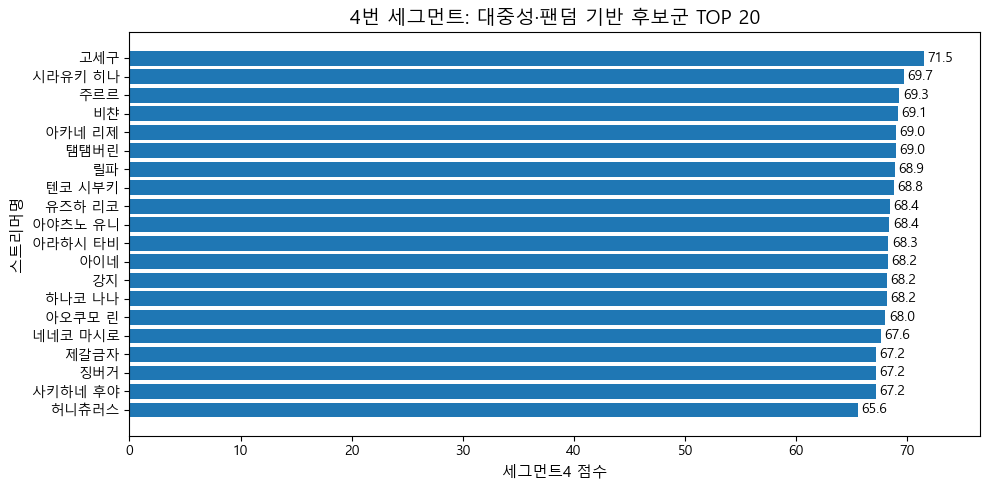

In [19]:
top20 = seg4_result.head(20).copy()

plt.figure(figsize=(10, 5))

plt.barh(top20["스트리머명"], top20["세그먼트4_score"])

for i, v in enumerate(top20["세그먼트4_score"]):
    plt.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=10)

plt.xlabel("세그먼트4 점수", fontsize=11)
plt.ylabel("스트리머명", fontsize=11)
plt.title("4번 세그먼트: 대중성·팬덤 기반 후보군 TOP 20", fontsize=14)

plt.xlim(0, top20["세그먼트4_score"].max() + 5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 소속구분 나누기

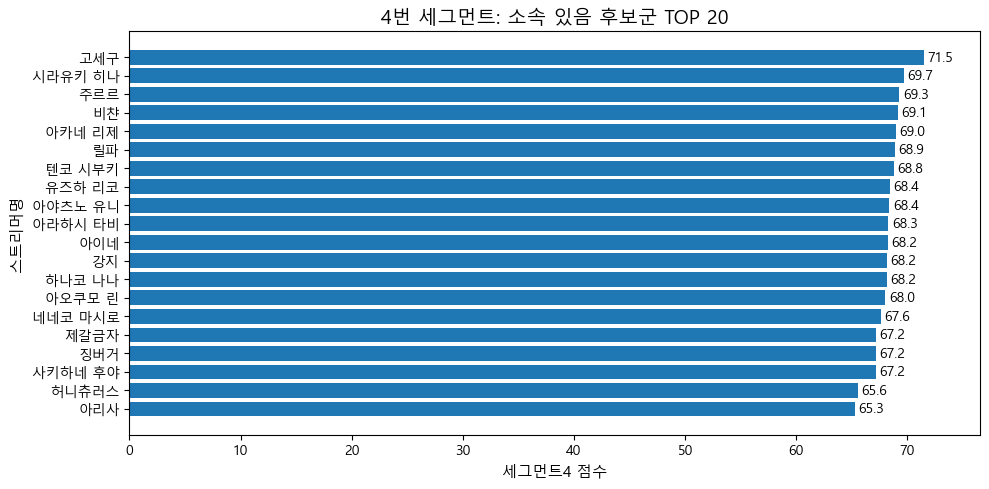

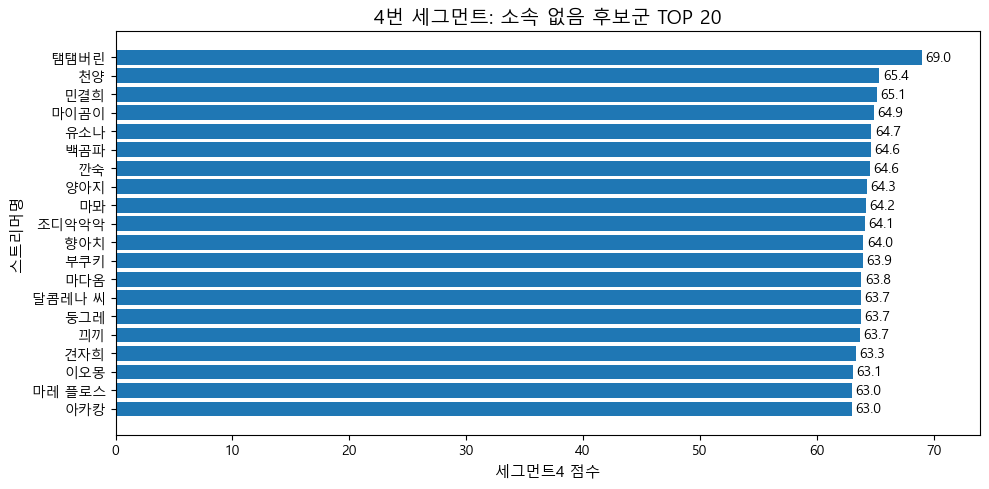

In [20]:
for status in ["소속 있음", "소속 없음"]:
    top20 = (
        seg4_result[seg4_result["소속여부"] == status]
        .sort_values("세그먼트4_score", ascending=False)
        .head(20)
        .copy()
    )

    plt.figure(figsize=(10, 5))

    plt.barh(top20["스트리머명"], top20["세그먼트4_score"])

    for i, v in enumerate(top20["세그먼트4_score"]):
        plt.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=10)

    plt.xlabel("세그먼트4 점수", fontsize=11)
    plt.ylabel("스트리머명", fontsize=11)
    plt.title(f"4번 세그먼트: {status} 후보군 TOP 20", fontsize=14)

    plt.xlim(0, top20["세그먼트4_score"].max() + 5)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# 그래프 2. 전체 TOP 20 점수 구성 누적 막대그래프

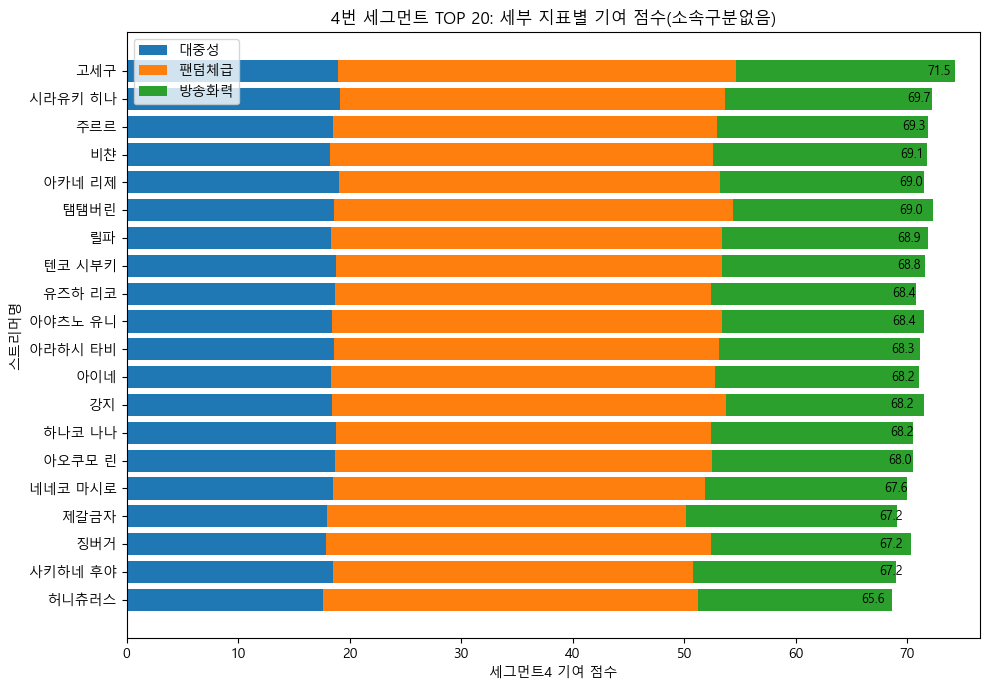

In [21]:
top20 = seg4_result.sort_values("세그먼트4_score", ascending=False).head(20).copy()

top20["대중성_기여점수"] = top20["대중성_score"] * 0.35
top20["팬덤체급_기여점수"] = top20["팬덤체급_score"] * 0.45
top20["방송화력_기여점수"] = top20["방송화력_score"] * 0.20

contribution_cols = ["대중성_기여점수", "팬덤체급_기여점수", "방송화력_기여점수"]

labels = {
    "대중성_기여점수": "대중성",
    "팬덤체급_기여점수": "팬덤체급",
    "방송화력_기여점수": "방송화력"
}

plt.figure(figsize=(10, 7))

left = np.zeros(len(top20))

for col in contribution_cols:
    plt.barh(
        top20["스트리머명"],
        top20[col],
        left=left,
        label=labels[col]
    )
    left += top20[col].values

# 숫자 표시 코드는 여기! for문 밖
for i, score in enumerate(top20["세그먼트4_score"]):
    plt.text(
        score + 0.3,
        i,
        f"{score:.1f}",
        va="center",
        fontsize=9
    )

plt.xlabel("세그먼트4 기여 점수")
plt.ylabel("스트리머명")
plt.title("4번 세그먼트 TOP 20: 세부 지표별 기여 점수(소속구분없음)")
plt.legend()
plt.xlim(0, top20["세그먼트4_score"].max() + 5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 소속구분 나누기

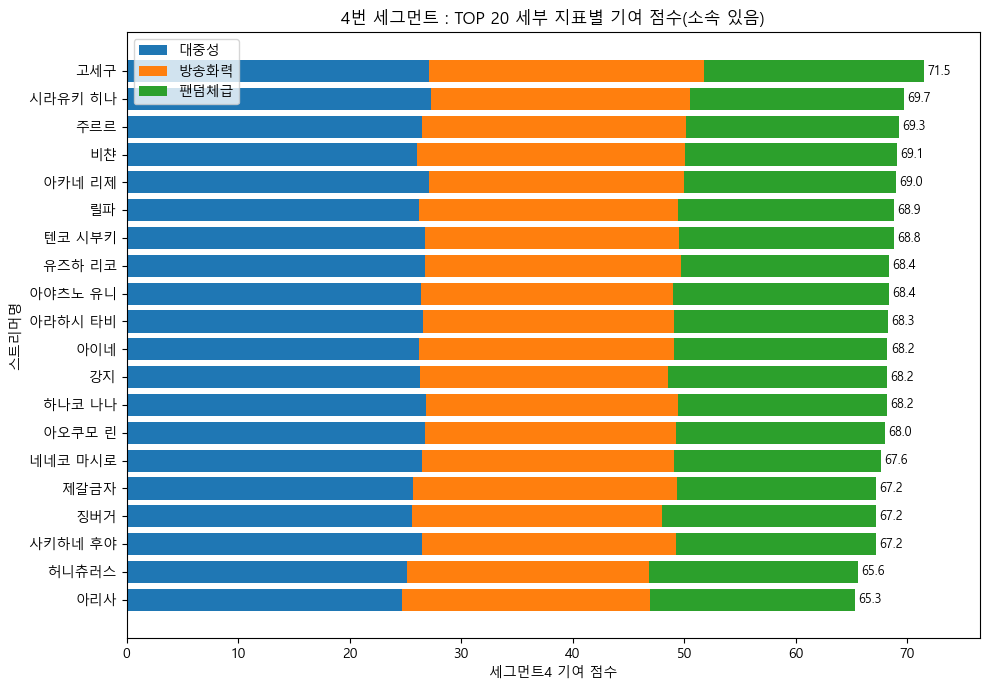

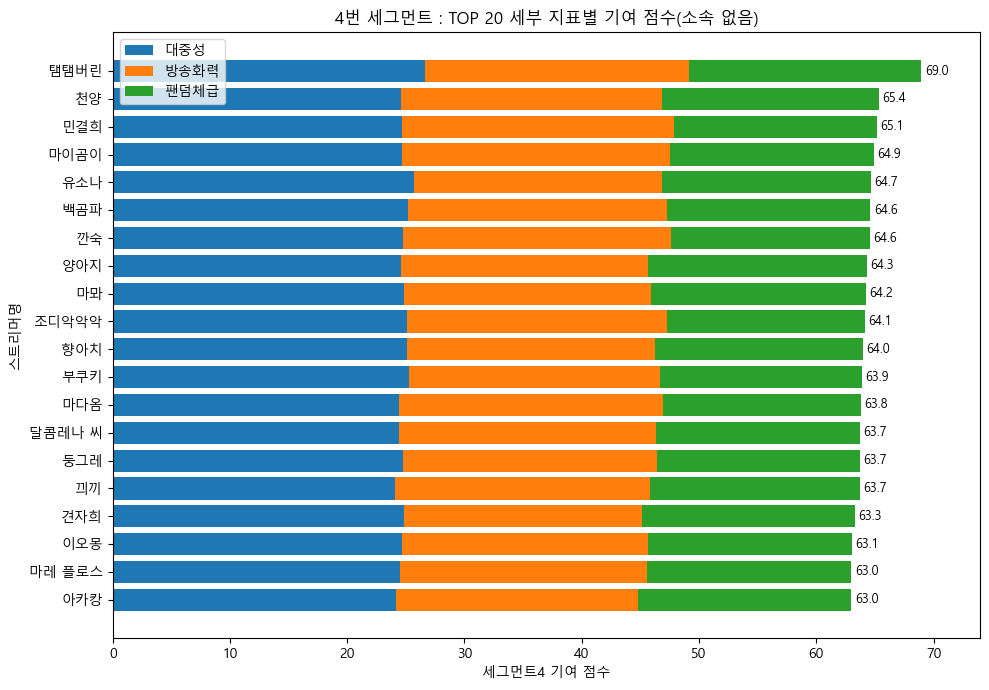

In [22]:
# 4번 세그먼트 가중치 기준
weights = {
    "대중성_score": 0.50,
    "팬덤체급_score": 0.25,
    "방송화력_score": 0.25
}

component_cols = ["대중성_score", "방송화력_score", "팬덤체급_score"]

for status in ["소속 있음", "소속 없음"]:
    top20 = (
        seg4_result[seg4_result["소속여부"] == status]
        .sort_values("세그먼트4_score", ascending=False)
        .head(20)
        .copy()
    )

    # 실제 최종 점수에 반영된 기여 점수 계산
    top20["대중성_기여점수"] = top20["대중성_score"] * weights["대중성_score"]
    top20["방송화력_기여점수"] = top20["방송화력_score"] * weights["방송화력_score"]
    top20["팬덤체급_기여점수"] = top20["팬덤체급_score"] * weights["팬덤체급_score"]

    contribution_cols = ["대중성_기여점수", "방송화력_기여점수", "팬덤체급_기여점수"]

    labels = {
        "대중성_기여점수": "대중성",
        "방송화력_기여점수": "방송화력",
        "팬덤체급_기여점수": "팬덤체급"
    }

    plt.figure(figsize=(10, 7))

    left = np.zeros(len(top20))

    for col in contribution_cols:
        plt.barh(
            top20["스트리머명"],
            top20[col],
            left=left,
            label=labels[col]
        )
        left += top20[col].values

    # 오른쪽에 최종 점수 숫자 표시
    for i, score in enumerate(top20["세그먼트4_score"]):
        plt.text(
            score + 0.3,
            i,
            f"{score:.1f}",
            va="center",
            fontsize=9
        )

    plt.xlabel("세그먼트4 기여 점수")
    plt.ylabel("스트리머명")
    plt.title(f"4번 세그먼트 : TOP 20 세부 지표별 기여 점수({status})")
    plt.legend()
    plt.xlim(0, top20["세그먼트4_score"].max() + 5)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# 그래프3. 대중성 vs 팬덤체급 + 방송화력 버블차트

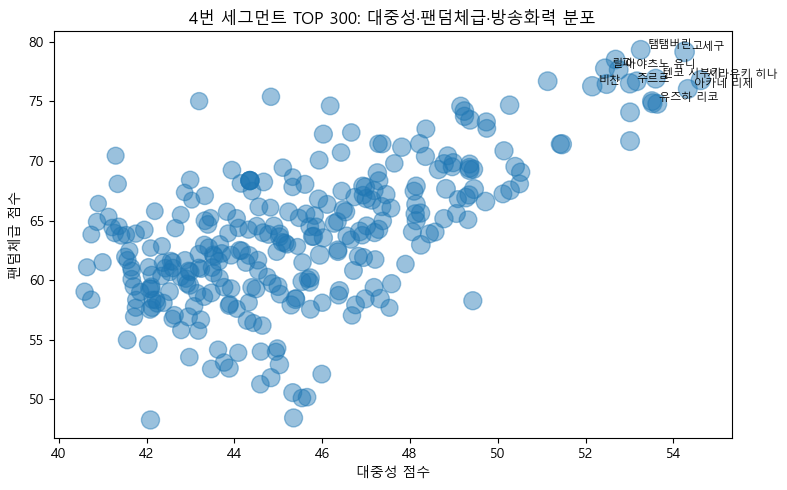

In [23]:
plot_df = seg4_result.head(300).copy()
label_df = seg4_result.head(10).copy()

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_df["대중성_score"],
    plot_df["팬덤체급_score"],
    s=plot_df["방송화력_score"] * 2,
    alpha=0.45
)

for _, row in label_df.iterrows():
    plt.text(
        row["대중성_score"] + 0.15,
        row["팬덤체급_score"] + 0.15,
        row["스트리머명"],
        fontsize=8
    )

plt.xlabel("대중성 점수")
plt.ylabel("팬덤체급 점수")
plt.title("4번 세그먼트 TOP 300: 대중성·팬덤체급·방송화력 분포")
plt.tight_layout()
plt.show()

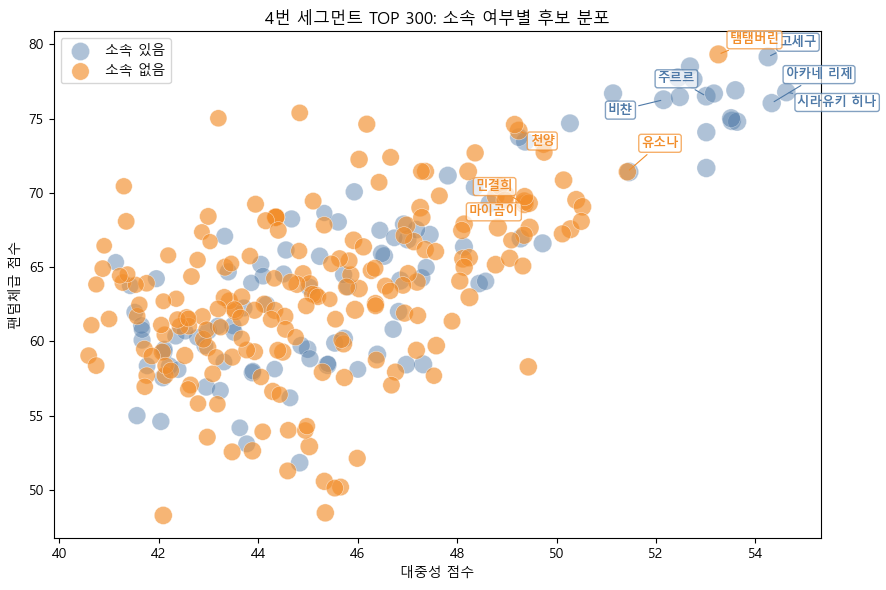

In [24]:
plt.figure(figsize=(9, 6))

colors = {
    "소속 있음": "#4E79A7",
    "소속 없음": "#F28E2B"
}

alphas = {
    "소속 있음": 0.45,
    "소속 없음": 0.65
}

offsets = [(8, 8), (8, -10), (-35, 10), (-40, -10), (10, 18)]

for status in ["소속 있음", "소속 없음"]:
    temp = plot_df[plot_df["소속여부"] == status].copy()

    plt.scatter(
        temp["대중성_score"],
        temp["팬덤체급_score"],
        s=temp["방송화력_score"] * 2,
        alpha=alphas[status],
        color=colors[status],
        label=status,
        edgecolor="white",
        linewidth=0.4
    )

    # 각 그룹별 상위 3명만 이름 표시
    label_df = temp.sort_values("세그먼트4_score", ascending=False).head(5)

    for i, (_, row) in enumerate(label_df.iterrows()):
        dx, dy = offsets[i % len(offsets)]

        plt.annotate(
            row["스트리머명"],
            xy=(row["대중성_score"], row["팬덤체급_score"]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=9,
            color=colors[status],   # 글씨색을 그룹 색과 동일하게
            fontweight="bold",
            arrowprops=dict(
                arrowstyle="-",
                color=colors[status],
                lw=0.8
            ),
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc="white",
                ec=colors[status],
                alpha=0.7
            )
        )

plt.xlabel("대중성 점수")
plt.ylabel("팬덤체급 점수")
plt.title("4번 세그먼트 TOP 300: 소속 여부별 후보 분포")
plt.legend()
plt.tight_layout()
plt.show()

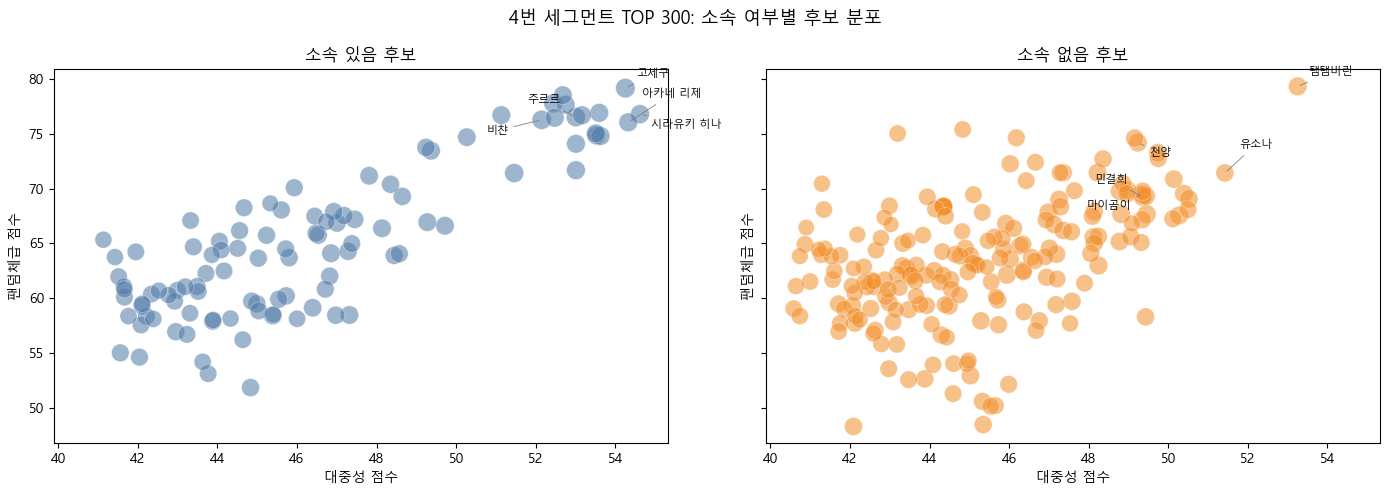

In [25]:
plot_df = seg4_result.sort_values("세그먼트4_score", ascending=False).head(300).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

colors = {
    "소속 있음": "#4E79A7",
    "소속 없음": "#F28E2B"
}

offsets = [(8, 8), (8, -10), (-35, 10), (-40, -10), (10, 18)]

for ax, status in zip(axes, ["소속 있음", "소속 없음"]):
    temp = plot_df[plot_df["소속여부"] == status].copy()
    label_df = temp.sort_values("세그먼트4_score", ascending=False).head(5)

    ax.scatter(
        temp["대중성_score"],
        temp["팬덤체급_score"],
        s=temp["방송화력_score"] * 2,
        alpha=0.55,
        color=colors[status],
        edgecolor="white",
        linewidth=0.4
    )

    for i, (_, row) in enumerate(label_df.iterrows()):
        dx, dy = offsets[i % len(offsets)]

        ax.annotate(
            row["스트리머명"],
            xy=(row["대중성_score"], row["팬덤체급_score"]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=8,
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.6)
        )

    ax.set_title(f"{status} 후보")
    ax.set_xlabel("대중성 점수")
    ax.set_ylabel("팬덤체급 점수")

plt.suptitle("4번 세그먼트 TOP 300: 소속 여부별 후보 분포", fontsize=13)
plt.tight_layout()
plt.show()

---
# 통계

### 1. TOP 후보군 기초통계

In [26]:
top_n = 300
top_df = seg4_result.head(top_n)

stat_cols = [
    "최고_팔로워",
    "최고_시청자",
    "평균_시청자_최댓값",
    "뷰어십",
    "도네이션",
    "유튜브_구독자",
    "팬덤지수",
    "유튜브_유입지수",
    "대중성_score",
    "방송화력_score",
    "팬덤체급_score",
    "세그먼트4_score"
]

top_df[stat_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
최고_팔로워,300.0,4.850647e+04,5.637720e+04,4554.000000,1.968575e+04,3.065400e+04,4.954900e+04,4.138620e+05
최고_시청자,300.0,7.876913e+03,7.597064e+03,738.000000,2.951000e+03,5.302500e+03,9.981250e+03,4.721800e+04
평균_시청자_최댓값,300.0,4.428757e+03,4.993103e+03,252.000000,1.330750e+03,2.435500e+03,5.604750e+03,3.095800e+04
뷰어십,300.0,1.401150e+06,2.207347e+06,33103.000000,2.921415e+05,6.328520e+05,1.491779e+06,1.707500e+07
도네이션,300.0,2.556581e+06,1.561403e+06,37809.000000,1.562306e+06,2.305230e+06,3.337459e+06,7.043167e+06
유튜브_구독자,300.0,1.062645e+05,2.046201e+05,382.000000,1.100000e+04,3.330000e+04,1.140000e+05,2.210000e+06
팬덤지수,300.0,-1.904667e+01,2.754206e+01,-100.000000,-2.332500e+01,-1.570000e+01,-5.900000e+00,3.730000e+01
유튜브_유입지수,300.0,3.586667e-01,1.304162e+01,-39.700000,-7.225000e+00,0.000000e+00,7.325000e+00,5.220000e+01
대중성_score,300.0,4.560322e+01,3.119459e+00,40.586623,4.319500e+01,4.506325e+01,4.732641e+01,5.462098e+01
방송화력_score,300.0,8.077833e+01,5.314026e+00,65.381332,7.706274e+01,8.029957e+01,8.421946e+01,9.845954e+01


TOP 300 후보군의 기초통계를 확인한 결과, 

전체 데이터 대비 팔로워, 최고 시청자, 뷰어십, 유튜브 구독자 등 대중성과 팬덤 규모 관련 지표가 높은 후보들이 상위권에 분포하는 것을 확인했다.

### 2. 전체 vs TOP 300 평균 비교

In [32]:
compare_cols = [
    "최고_팔로워",
    "최고_시청자",
    "평균_시청자_최댓값",
    "뷰어십",
    "도네이션",
    "유튜브_구독자",
    "유튜브_유입지수",
    "팬덤지수"
]

compare_stat = pd.DataFrame({
    "전체_평균": seg4_df[compare_cols].mean(),
    "TOP300_평균": top_df[compare_cols].mean(),
    "평균차이": top_df[compare_cols].mean() - seg4_df[compare_cols].mean()
})

compare_stat

,전체_평균,TOP300_평균,평균차이
최고_팔로워,2309.257775,4.850647e+04,4.619721e+04
최고_시청자,361.722775,7.876913e+03,7.515191e+03
평균_시청자_최댓값,181.134714,4.428757e+03,4.247622e+03
뷰어십,53877.616205,1.401150e+06,1.347272e+06
도네이션,237862.724926,2.556581e+06,2.318719e+06
유튜브_구독자,4630.698306,1.062645e+05,1.016338e+05
유튜브_유입지수,-46.016510,3.586667e-01,4.637518e+01
팬덤지수,-55.965206,-1.904667e+01,3.691854e+01


전체 평균과 TOP 300 후보군의 평균을 비교해 후보군의 특성을 확인했다.  
TOP 300은 전체 대비 팔로워, 최고 시청자, 평균 시청자, 뷰어십, 도네이션, 유튜브 구독자 등 주요 규모 지표가 전반적으로 높게 나타났다.

### 3. 결측/0값 비율 확인

In [28]:
check_cols = [
    "X_팔로워",
    "유튜브_구독자",
    "팬카페_가입자",
    "유튜브_유입지수",
    "팬덤지수"
]

missing_zero_stat = pd.DataFrame({
    "결측수": df[check_cols].isna().sum(),
    "결측비율": df[check_cols].isna().mean(),
    "0값수": (df[check_cols] == 0).sum(),
    "0값비율": (df[check_cols] == 0).mean()
})

missing_zero_stat

,결측수,결측비율,0값수,0값비율
X_팔로워,0,0.0,8280,0.742135
유튜브_구독자,0,0.0,4277,0.383347
팬카페_가입자,0,0.0,5819,0.521556
유튜브_유입지수,0,0.0,65,0.005826
팬덤지수,0,0.0,54,0.004840


외부 팬덤 관련 지표의 결측 및 0값 비율을 확인했다.

확인 결과 결측값은 없었지만, X 팔로워, 유튜브 구독자, 팬카페 가입자 등 외부 팬덤 지표에서 0값 비율이 높게 나타났다.

따라서 외부 팬덤 지표는 일부 후보에게 유리하거나 불리하게 작용할 수 있으므로, 최종 점수에서는 보조 지표로 해석하는 것이 적절하다.

### 4. 점수 간 상관관계

In [29]:
score_corr_cols = [
    "대중성_score",
    "방송화력_score",
    "팬덤체급_score",
    "세그먼트4_score"
]

seg4_df[score_corr_cols].corr()

,대중성_score,방송화력_score,팬덤체급_score,세그먼트4_score
대중성_score,1.000000,0.871480,0.914533,0.980043
방송화력_score,0.871480,1.000000,0.771067,0.927518
팬덤체급_score,0.914533,0.771067,1.000000,0.940805
세그먼트4_score,0.980043,0.927518,0.940805,1.000000


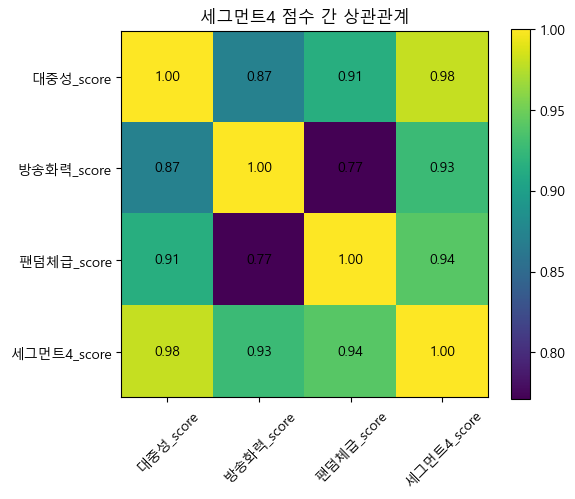

In [34]:
corr_matrix = seg4_df[score_corr_cols].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix)

plt.xticks(range(len(score_corr_cols)), score_corr_cols, rotation=45)
plt.yticks(range(len(score_corr_cols)), score_corr_cols)
plt.colorbar()

# 숫자 표시 추가
for i in range(len(score_corr_cols)):
    for j in range(len(score_corr_cols)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=10
        )

plt.title("세그먼트4 점수 간 상관관계")
plt.tight_layout()
plt.show()

세그먼트4 최종 점수와 하위 점수 간 상관관계를 확인했다.

세그먼트4_score는 대중성_score와 가장 높은 상관관계를 보였으며, 팬덤체급_score와 방송화력_score 역시 높은 상관관계를 보였다.

이는 4번 세그먼트가 대중성을 중심으로 하되, 팬덤 규모와 방송 반응을 함께 반영하는 후보군 선정 구조임을 보여준다.

### 5. 플랫폼별 TOP 후보 분포

In [31]:
platform_top_count = top_df["플랫폼"].value_counts()
platform_top_ratio = top_df["플랫폼"].value_counts(normalize=True)

pd.DataFrame({
    "TOP300_인원수": platform_top_count,
    "TOP300_비율": platform_top_ratio
})

,TOP300_인원수,TOP300_비율
플랫폼,,
CHZZK,159,0.53
SOOP,141,0.47


후보군 선정에는 플랫폼을 직접적인 가중치로 반영하지 않았지만, 결과 해석을 위해 TOP 300 내 플랫폼 분포를 확인했다.

TOP 300 후보군은 CHZZK 159명, SOOP 141명으로 비교적 고르게 분포했다.

따라서 4번 세그먼트 후보군이 특정 플랫폼에 과도하게 치우치기보다는 양 플랫폼에서 모두 도출되었음을 확인했다.